In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config
set_config(transform_output='pandas')

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

data = pd.read_csv(r"C:\Users\User\Downloads\4_housing_iteration_5_classification\housing_iteration_5_classification\housing_iteration_5_classification.csv")

data = data.set_index("Id")

y = data['Expensive'].copy()
X = data.drop('Expensive', axis=1).copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

X_num_cols = X.select_dtypes(include='number').columns
cat_imputer = SimpleImputer(strategy='constant', fill_value='N_A')
oneHot_encoder = OneHotEncoder(handle_unknown='infrequent_if_exist', sparse_output=False)


ordinal_features = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
    'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 
    'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]


ordinal_categories = [
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                    
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],              
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['NA', 'No', 'Mn', 'Av', 'Gd'],                    
    ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],  
    ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                    
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                    
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],              
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],              
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],              
    ['NA', 'Fa', 'TA', 'Gd', 'Ex']                     
]

# ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)
ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_cat_cols= X.select_dtypes(exclude='number').columns
oneHot_feat = list(set(X_cat_cols) - set(ordinal_features))

encoder = make_column_transformer(
    (ordinal_encoder, ordinal_features),
    (oneHot_encoder, oneHot_feat)
)

num_pipe = make_pipeline( SimpleImputer(strategy='mean'))

cat_pipe = make_pipeline(cat_imputer, encoder)

preprocessor = make_column_transformer(
    (num_pipe, X_num_cols),
    (cat_pipe, X_cat_cols))

full_pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=42))

param_grid = {
    "randomforestclassifier__n_estimators": [200, 300],
    "randomforestclassifier__max_depth": [5, 10, 15, 20],
    "randomforestclassifier__min_samples_split": [5, 10, 20],
    "randomforestclassifier__min_samples_leaf": [2, 4, 8],
    "randomforestclassifier__max_features": ["sqrt", "log2"],
    "randomforestclassifier__class_weight": [None, {0:2, 1:1}]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

RFC_pipe = RandomizedSearchCV(
    full_pipe,
    param_grid,
    n_iter=50,
    cv=cv,
    scoring="accuracy", 
    verbose=1,
    random_state=42,
    n_jobs=1
)

RFC_pipe.fit(X_train, y_train)

from sklearn.metrics import r2_score

y_pred = RFC_pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(r2)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
0.6384761904761904


In [2]:
accuracy_score(y_true=y_train,
               y_pred=RFC_pipe.predict(X_train))

0.990582191780822

In [3]:
assessment_df = pd.DataFrame(columns=['train', 'test'], index=['RFC_baseline'])
assessment_df.loc['RFC_baseline', 'train'] = accuracy_score(y_true=y_train, y_pred=RFC_pipe.predict(X_train))
assessment_df.loc['RFC_baseline', 'test'] = accuracy_score(y_true=y_test, y_pred=RFC_pipe.predict(X_test))
assessment_df

,train,test
RFC_baseline,0.990582,0.955479


Test Accuracy: 0.9554794520547946
Test Recall: 0.7380952380952381
Test Precision: 0.9393939393939394
Test F1: 0.8266666666666667
Test Cohen's Kappa: 0.801547469677959


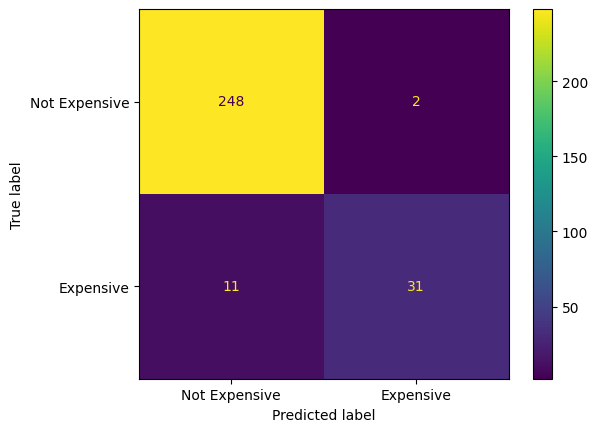

In [4]:
best_model = RFC_pipe.best_estimator_
test_pred = best_model.predict(X_test)

from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, cohen_kappa_score

print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Test Recall:", recall_score(y_test, test_pred))
print("Test Precision:", precision_score(y_test, test_pred))
print("Test F1:", f1_score(y_test, test_pred))
print("Test Cohen's Kappa:", cohen_kappa_score(y_test, test_pred))


from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
  RFC_pipe,
  X_test,
  y_test,
  display_labels=['Not Expensive', 'Expensive']
)

In [94]:
RFC_pipe.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'randomforestclassifier__class_weight': [None, {0: 2, 1: 1}], 'randomforestclassifier__max_depth': [5, 10, ...], 'randomforestclassifier__max_features': ['sqrt', 'log2'], 'randomforestclassifier__min_samples_leaf': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same a

In [95]:
accuracy_score(y_true=y,
               y_pred=RFC_pipe.predict(X))

0.9931506849315068

Test Accuracy: 0.9931506849315068
Test Recall: 0.9631336405529954
Test Precision: 0.990521327014218
Test F1: 0.9766355140186916
Test Cohen's Kappa: 0.9726235969593442


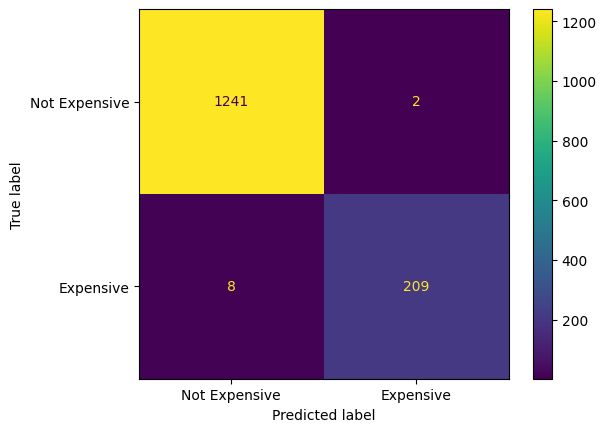

In [96]:
best_model = RFC_pipe.best_estimator_
test_pred = best_model.predict(X)

from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, cohen_kappa_score

print("Test Accuracy:", accuracy_score(y, test_pred))
print("Test Recall:", recall_score(y, test_pred))
print("Test Precision:", precision_score(y, test_pred))
print("Test F1:", f1_score(y, test_pred))
print("Test Cohen's Kappa:", cohen_kappa_score(y, test_pred))


from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
  RFC_pipe,
  X,
  y,
  display_labels=['Not Expensive', 'Expensive']
)

In [97]:
url = "https://drive.google.com/file/d/15PfmTxmavQCT-f7iY9tgwWxm9t4GRees/view?usp=drive_link"
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
testing_data = pd.read_csv(path)
testing_data = testing_data.set_index('Id')

In [98]:
testing_data.shape

(1459, 79)

In [99]:
RFC_pipe.predict(testing_data)
# df = pd.DataFrame(comp)
# df.value_counts()

array([0, 0, 0, ..., 0, 0, 0], shape=(1459,))

In [100]:
testing_data['Expensive'] = RFC_pipe.predict(testing_data)

In [101]:
testing_data['Expensive'].to_csv(r"C:\Users\User\Downloads\4_housing_iteration_5_classification\housing_iteration_5_classification\submission11.csv")